In [1]:
from __future__ import annotations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
#%matplotlib notebook
%matplotlib widget

import os
import pickle

import sys
sys.path.append("../../src/utils")
from utils import *

from grain_generator import AdaptiveGrainGenerator
from magtense.micromag import MicromagProblem
from typing import Optional
from itertools import product

In [2]:
rng_seed = 100
rng = np.random.default_rng(rng_seed)
gen = AdaptiveGrainGenerator(n_grains=25, offset_d=4e-9, rng=rng)
gen.generate(res_base=6, num_refinements=2)

Mesh generated: 10191 tiles in 2.76s.


In [3]:
quick_test = False # if true, then only run FMM with nlmax=2

exma_file =  "seed_" + str(rng_seed) + "_exMa.npz"
demag_file = "seed_" + str(rng_seed) + "_demag.bin"

mu0 = 4 * np.pi * 1e-7
alpha = 4000.0
gamma = 0.0
grid_type = "unstructuredPrisms"
#H_ext_dir = rng.random(3)          # For random direction, but "fixed" for reproducibility
#H_ext_dir = np.random.random(3)    # For random direction, without reproducibility
H_ext_dir = np.array([0., 0., 1.])     # For fixed direction along Z
H_ext_dir /= np.linalg.norm(H_ext_dir)

def h_ext_fct(t: np.ndarray) -> np.ndarray:
    return H_ext_dir

In [4]:
def fmm_test_setup(
                gen: AdaptiveGrainGenerator,
                cuda: bool = True,
                cvode: bool = False,
                cone_angle_degree: float = 20,
                easy_axis_cone_degree: float = 20,
                H_ext_dir: np.ndarray = np.array([0., 0., 1.]),
                passexch: int = 0,
                input_file_name : str = "t",
                timer_log_file: str = "timer_test.log",
                trace_log_file: str = "trace_test.log",
                t_end: float = 40e-9,
                nt: int = 10,
                dummy_run: int = 0,
                nlmax: int = 2,
                allow_fmm_short_circuit: int = 0,
                fmm_min_n: int = 20000,
                fmm_nterms: int = 6, 
                exch_val: list | np.ndarray | None = None,
                exch_rows: list | np.ndarray | None = None,
                exch_col: list | np.ndarray | None = None,
                exch_nval: int = 1,
                exch_nrow: int = 1,
                exch_ncols: int = 1,
                rng: Optional[np.random.Generator] = None,  #
                ) -> MicromagProblem:
        #------------ extract mesh and grid info from generator ------------
        mesh_cart = gen.mesh_cart
        grid_info = gen.grid_info
        n_grains = gen.n_grains
        grid_pts = mesh_cart["pos_out"]
        grid_abc = mesh_cart["dims_out"]
        grain_indices = mesh_cart["GrainIndex"]  # Expected 1D array
        n_cell = grid_pts.shape[0]
        grid_L = gen.grid_l
        res = gen.mesh_params["resolution"]
        #--------------------------------------------------------------
        # --- Material Constants (Based on  standard grain problem) ---
        mu0 = 4 * np.pi * 1e-7
        #----------- grain parameters -----------
        Ms_val = 1.61 / mu0      # 1.61 T
        K0_val = 4.3e6           # J/m3
        A0_val = 7.7e-12         # J/m
        #----------- intergrain parameters -----------
        Ms_ig = 0.5 / mu0        # Intergrain Ms
        A0_ig_factor = 1.0       # Intergrain exchange factor
        #--------------------------------------------------------------

        # --- Generate Easy Axis directions (mag_dir) ---
        # Using 180 degrees for fully random grain orientations on the sphere
        # centered arbitrarily on Z [source: 1]
        grain_mag_dirs = rand_spherical_cap(
                cone_angle_degree=easy_axis_cone_degree, 
                N=n_grains, 
                cone_dir=H_ext_dir, 
                rng=rng
        )

        # --- Initialize MicromagProblem ---
        problem = MicromagProblem(
                res=res,
                grid_L=grid_L,
                alpha=alpha,
                gamma=gamma,
                grid_pts=grid_pts,
                grid_abc=grid_abc,
                grid_type=grid_type,
                cuda=cuda,
                cvode=cvode,
                exch_val=exch_val,
                exch_rows=exch_rows,
                exch_col=exch_col,
                exch_nval=exch_nval,
                exch_nrow=exch_nrow,
                exch_ncols=exch_ncols,
                passexch=passexch,
                filename=input_file_name,
        )

        # --- Assign Material Properties and Easy Axes per Grain ---
        problem.Ms = Ms_val * np.ones((n_cell, 1))
        problem.K0 = K0_val * np.ones((n_cell, 1))
        problem.A0 = A0_val * np.ones((n_cell, 1))

        # Grain 1 to N: Set Easy Axis
        for g_idx in range(1, n_grains + 1):
                cell_mask = (grain_indices == g_idx)
                problem.u_ea[cell_mask, :] = grain_mag_dirs[g_idx - 1]


        # Intergrain (ID = N+1): Set Properties
        ig_mask = (grain_indices == n_grains + 1)
        problem.Ms[ig_mask] = Ms_ig
        problem.A0[ig_mask] = A0_val * A0_ig_factor
        # u_ea for intergrain is usually 0 (already default)


        # --- Set Initial Magnetization (m0) ---------------
        # 1. Grains: Along the Easy Axis
        for g_idx in range(1, n_grains + 1):
                cell_mask = (grain_indices == g_idx)
                problem.m0[cell_mask, :] = grain_mag_dirs[g_idx - 1]
        # 2. Intergrain: Random within a cone [source: 1]
        n_ig = np.sum(ig_mask)
        if n_ig > 0:
                # Standard cone randomization around the Z-axis for the intergrain phase
                ig_m0 = rand_spherical_cap(
                        cone_angle_degree=cone_angle_degree, 
                        N=n_ig, 
                        cone_dir=H_ext_dir, 
                        rng=rng
                )
                problem.m0[ig_mask, :] = ig_m0
        #-------------------------------------------------------------

        problem.solver = "dynamic"

        t = np.linspace(0, t_end, nt)
        problem.t =  t
        problem.nt = nt


        nnbor = 27 # assmue 27 nearest neighbors for exchange
        problem.exch_presize = problem.nt * (nnbor+1)

        problem.dummy_run = dummy_run



        problem.fmm_cells_per_node = 10
        problem.fmm_eps = 1e-4
        problem.ifunif = 1
        problem.nlmin = 1
        problem.nlmax = nlmax
        problem.allow_fmm_short_circuit = allow_fmm_short_circuit
        problem.fmm_min_n = fmm_min_n
        problem.fmm_nterms = fmm_nterms



        problem.log_dir = "timer_logs"
        problem.timer_log_file = timer_log_file
        problem.trace_log_file = trace_log_file
        problem.window_enabled = 1
        problem.window_interval = 15.0
        problem.trace_enabled = 0
        problem.flush_each = 1
        problem.trace_verbose = 1

        problem.usereturnhall = True

        return problem

In [5]:
t_end = 40e-9

if not Path(exma_file).exists():
    print("Running problem to generate exMa...")

    rng = np.random.default_rng(rng_seed)
    problem = fmm_test_setup(
        gen=gen,
        allow_fmm_short_circuit=1,
        timer_log_file="dummy_" + str(rng_seed) + "_timer.log",
        trace_log_file="dummy_" + str(rng_seed) + "_trace.log",
        input_file_name=demag_file,
        rng=np.random.default_rng(rng_seed),
        H_ext_dir=H_ext_dir,
        dummy_run=1
        )

    res = problem.run_simulation(
        t_end=t_end,
        nt=problem.nt,
        fct_h_ext=h_ext_fct,
        nt_h_ext=problem.nt)
    exch_nval, ExchMat_r, ExchMat_c, ExchMat_v, exch_nrow, exch_ncols = res[7:]
    print("storing setup...")
    print("exch_nval = ", exch_nval)
    print("exch_nrow = ", exch_nrow)
    print("exch_ncols = ", exch_ncols)
    print("shape ExchMat_r", ExchMat_r.shape)
    print("shape ExchMat_c", ExchMat_c.shape)
    print("shape ExchMat_v", ExchMat_v.shape)
    print("ExchMat_v[:10] = ", ExchMat_v[:10])
    np.savez(
        exma_file,
        exch_nval=exch_nval,
        ExchMat_r=ExchMat_r,
        ExchMat_c=ExchMat_c,
        ExchMat_v=ExchMat_v,
        exch_nrow=exch_nrow,
        exch_ncols=exch_ncols
    )   
    print(f"Saved exchange matrix to {exma_file}")
exch_nval, ExchMat_r, ExchMat_c, ExchMat_v, exch_nrow, exch_ncols = np.load(
    exma_file, allow_pickle=True
).values()

In [6]:
# Common configuration to avoid repetition
common_setup = {
    "gen": gen,
    "passexch": 1,
    "input_file_name": demag_file,
    "exch_val": ExchMat_v,
    "exch_rows": ExchMat_r,
    "exch_col": ExchMat_c,
    "exch_nval": exch_nval,
    "exch_nrow": exch_nrow,
    "exch_ncols": exch_ncols,
    "H_ext_dir": H_ext_dir,
}

# Define the parameter space
if quick_test:
    nlmax_list = [2]
else:
    nlmax_list = [2, 3]
nterms_list = [6, 10, 15]

results = {}

# --- 1. Run CUDA Baseline ---
print("Running CUDA Baseline...")
problem_cuda = fmm_test_setup(
    **common_setup,
    allow_fmm_short_circuit=1,
    timer_log_file=f"cuda_{rng_seed}_timer.log",
    trace_log_file=f"cuda_{rng_seed}_trace.log",
    rng = np.random.default_rng(rng_seed)
)
res_cuda = problem_cuda.run_simulation(
    t_end=t_end, nt=problem_cuda.nt, 
    fct_h_ext=h_ext_fct, nt_h_ext=problem_cuda.nt
)
results["CUDA"] = {"Mout": res_cuda[1], "Hdem": res_cuda[5]}

# --- 2. Run FMM Iterations ---
for nl, nt_fmm in product(nlmax_list, nterms_list):
    config_label = f"FMM_L{nl}_N{nt_fmm}"
    print(f"Running {config_label}...")
    
    prob = fmm_test_setup(
        **common_setup,
        allow_fmm_short_circuit=0,
        nlmax=nl,
        fmm_nterms=nt_fmm,
        timer_log_file=f"{config_label}_{rng_seed}_timer.log",
        trace_log_file=f"{config_label}_{rng_seed}_trace.log",
        rng = np.random.default_rng(rng_seed)
    )
    
    res = prob.run_simulation(
        t_end=t_end, nt=prob.nt, 
        fct_h_ext=h_ext_fct, nt_h_ext=prob.nt
    )
    results[config_label] = {"Mout": res[1], "Hdem": res[5]}

Running CUDA Baseline...
dummy run in python =  0
OpenMP runtime info
  _OPENMP (macro)        : 202011
  OpenMP spec (mapped)   : 5.1
  num_threads (team)     : 16
  max_threads            : 16
  num_procs              : 48
  dynamic teams          : F
  max active levels      : 2
  nested parallel        : T
  proc_bind              : close           
  schedule               : static, chunk=  1
  num_places             : 24
Per-thread placement:
------------------------------------------------------------
  tid=0  place=0
  tid=1  place=1
  tid=2  place=2
Running FMM_L2_N6...  tid=3  place=3
  tid=4  place=4
  tid=5  place=5
  tid=6  place=6
  tid=7  place=7
  tid=8  place=8
  tid=9  place=9
  tid=10  place=10
  tid=11  place=11
  tid=12  place=12
  tid=13  place=13
  tid=14  place=14
  tid=15  place=15
 Passing exchange matrix
 Creating Exchange matrix start
 Creating Exchange matrix end
 Initializing matrices
  built tree with            2  levels and           73  boxes 
  Number

/home/mihaa/MagTense/python/src/magtense/micromag.py:566: RuntimeWarning: invalid value encountered in cast
  result = magtensesource.fortrantopythonio.runmicromagsimulation(


dummy run in python =  0
OpenMP runtime info
  _OPENMP (macro)        : 202011
  OpenMP spec (mapped)   : 5.1
  num_threads (team)     : 16
  max_threads            : 16
  num_procs              : 48
  dynamic teams          : F
  max active levels      : 2
  nested parallel        : T
  proc_bind              : close           
  schedule               : static, chunk=  1
  num_places             : 24
Per-thread placement:
------------------------------------------------------------
  tid=0  place=0
  tid=1  place=1
  tid=2  place=2
  tid=3  place=3
  tid=4  place=4
Running FMM_L2_N10...  tid=5  place=5
  tid=6  place=6
  tid=7  place=7
  tid=8  place=8
  tid=9  place=9
  tid=10  place=10
  tid=11  place=11
  tid=12  place=12
  tid=13  place=13
  tid=14  place=14
  tid=15  place=15
 Passing exchange matrix
 Creating Exchange matrix start
 Creating Exchange matrix end
 Initializing matrices
  built tree with            2  levels and           73  boxes 
  Number of multipole expansion 

In [7]:
def plot_all_comparisons(results, target_cell_idx=9):
    components = ['x', 'y', 'z']
    fields = ['Hdem', 'Mout']
    cuda = results["CUDA"]
    
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    fig.suptitle(f"FMM vs CUDA Error Analysis (Cell {target_cell_idx})", fontsize=16, fontweight='bold')

    for col, field in enumerate(fields):
        for row, comp in enumerate(components):
            ax = axes[row, col]
            cuda_data = cuda[field][target_cell_idx, :, 0, row]
            norm = np.mean(np.abs(cuda_data)) if field == "Hdem" else 1.0
            
            for label, data in results.items():
                if label == "CUDA": continue
                fmm_data = data[field][target_cell_idx, :, 0, row]
                error = (cuda_data - fmm_data) / norm
                ax.plot(error, label=label)

            ax.set_title(f"{field} - {comp.upper()}")
            ax.grid(True, linestyle='--', alpha=0.6)
            if row == 0 and col == 1:
                ax.legend(loc='upper right', fontsize='8')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    # Return the figure object instead of just calling plt.show()
    return fig

def calculate_error_metrics(results, target_cell_idx=9):
    metrics_list = []
    cuda = results["CUDA"]
    
    for label, data in results.items():
        if label == "CUDA": continue
        
        entry = {"Config": label}
        
        for field in ["Hdem", "Mout"]:
            # Combine x, y, z for a total field error [time, 3]
            c_data = cuda[field][target_cell_idx, :, 0, :]
            f_data = data[field][target_cell_idx, :, 0, :]
            
            diff = np.abs(c_data - f_data)
            
            # Standard Errors
            entry[f"{field}_avg"] = np.mean(diff)
            entry[f"{field}_max"] = np.max(diff)
            
            # Relative Errors (Hdem only)
            if field == "Hdem":
                norm = np.mean(np.abs(c_data))
                entry["Hdem_rel_avg"] = entry["Hdem_avg"] / norm
                entry["Hdem_rel_max"] = entry["Hdem_max"] / norm
                
        metrics_list.append(entry)
        
    return metrics_list

def validate_results(metrics, threshold_map, default_key="L2"):
    """
    Validates results based on config-specific thresholds.
    threshold_map: {
        "L2": {"Hdem_rel_avg": 0.01, ...},
        "L3": {"Hdem_rel_avg": 0.02, ...}
    }
    """
    header = f"{'Configuration':<15} | {'Status':<8} | {'Limit Used':<10} | Errors Found"
    print(f"\n{header}")
    print("-" * 85)
    
    overall_pass = True
    
    for m in metrics:
        # Determine which threshold set to use based on the label
        # Checks if "L2", "L3", etc., is in the config string
        active_thresholds = None
        limit_label = "Default"
        
        for key in threshold_map:
            if key in m['Config']:
                active_thresholds = threshold_map[key]
                limit_label = key
                break
        
        # Fallback to default if no match found
        if active_thresholds is None:
            active_thresholds = threshold_map.get(default_key, {})
            limit_label = default_key

        failures = []
        for metric_name, limit in active_thresholds.items():
            val = m.get(metric_name, 0)
            if val > limit:
                failures.append(f"{metric_name}({val:.2e} > {limit:.2e})")
        
        status = "✅ PASS" if not failures else "❌ FAIL"
        if failures: 
            all_passed = False
        
        overall_pass = overall_pass and (not failures)


        error_str = ", ".join(failures) if failures else "Within tolerance"
        print(f"{m['Config']:<15} | {status:<8} | {limit_label:<10} | {error_str}")
        
    print("-" * 85)
    if overall_pass:
        print("OVERALL TEST SUITE: SUCCESS 🚀")
    else:
        print("OVERALL TEST SUITE: FAILURE 💀")
    
    return overall_pass

In [8]:
def save_experiment_data(seed, results, metrics, fig=None):
    """
    Saves simulation results, error metrics, and the comparison plot
    into a seed-specific subfolder.
    """
    # Create the base results directory
    base_dir = "results"
    if not os.path.exists(base_dir):
        os.makedirs(base_dir)
        
    # Create the seed-specific subfolder
    subfolder = os.path.join(base_dir, "seed_" + str(seed))
    if not os.path.exists(subfolder):
        os.makedirs(subfolder)
    
    # Save the results variable (binary)
    results_path = os.path.join(subfolder, "results.pkl")
    with open(results_path, 'wb') as f:
        pickle.dump(results, f)
        
    # Save the metrics variable (binary)
    metrics_path = os.path.join(subfolder, "metrics.pkl")
    with open(metrics_path, 'wb') as f:
        pickle.dump(metrics, f)
        
    # Save the figure if provided
    if fig is not None:
        fig_path = os.path.join(subfolder, "comparison_plot.png")
        fig.savefig(fig_path)
        print(f"Figure saved to: {fig_path}")

    print(f"Experiment data for seed {seed} saved successfully in '{subfolder}'.")

def load_experiment_data(seed):
    """
    Loads simulation results and metrics from a seed-specific subfolder.
    """
    subfolder = os.path.join("results", "seed_" + str(seed))
    
    results_path = os.path.join(subfolder, "results.pkl")
    metrics_path = os.path.join(subfolder, "metrics.pkl")
    
    if not os.path.exists(results_path) or not os.path.exists(metrics_path):
        raise FileNotFoundError(f"No saved data found for seed {seed} in {subfolder}")

    with open(results_path, 'rb') as f:
        results = pickle.load(f)
        
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
        
    print(f"Data for seed {seed} loaded successfully.")
    return results, metrics

Figure saved to: results/seed_100/comparison_plot.png
Experiment data for seed 100 saved successfully in 'results/seed_100'.

Configuration   | Status   | Limit Used | Errors Found
-------------------------------------------------------------------------------------
FMM_L2_N6       | ✅ PASS   | L2         | Within tolerance
FMM_L2_N10      | ✅ PASS   | L2         | Within tolerance
FMM_L2_N15      | ✅ PASS   | L2         | Within tolerance
FMM_L3_N6       | ❌ FAIL   | L3         | Mout_max(2.17e-01 > 2.00e-01)
FMM_L3_N10      | ❌ FAIL   | L3         | Mout_max(2.31e-01 > 2.00e-01)
FMM_L3_N15      | ❌ FAIL   | L3         | Mout_max(2.31e-01 > 2.00e-01)
-------------------------------------------------------------------------------------
OVERALL TEST SUITE: FAILURE 💀


False

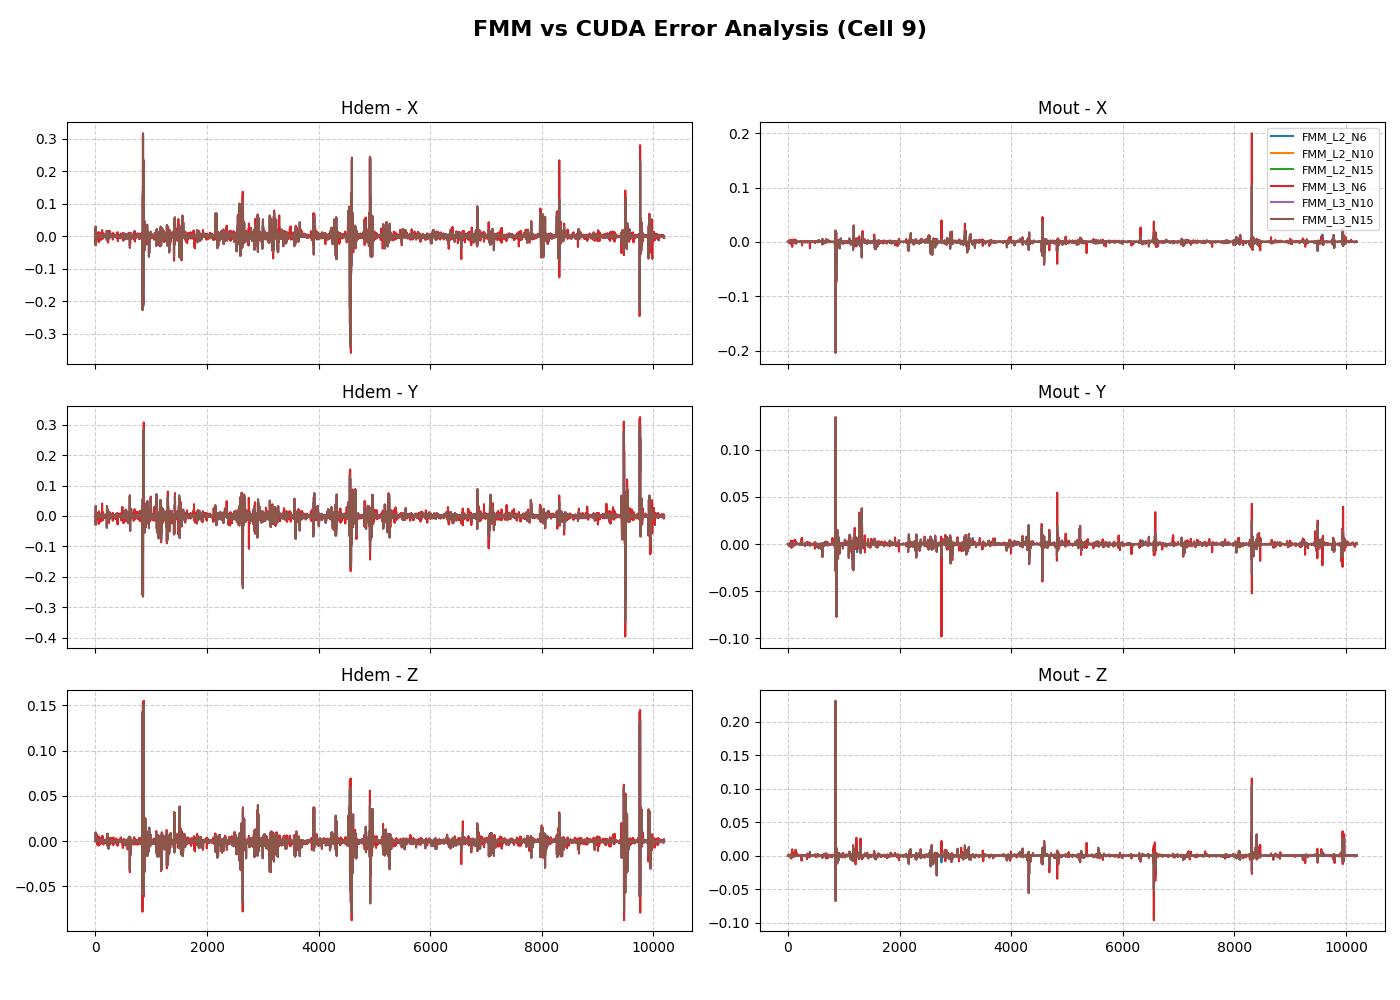

In [9]:

# --- 1.  Calculate Metrics ---
# (Assuming your loop to populate 'results' has finished)
metrics = calculate_error_metrics(results)

# --- 2. Generate and Capture the Plot ---
comparison_fig = plot_all_comparisons(results)
#plt.show() # Display it in your notebook/UI

# --- 3. Save Everything ---
save_experiment_data(
    seed=rng_seed, 
    results=results, 
    metrics=metrics, 
    fig=comparison_fig
)


# Define specific tolerances for different FMM levels
fmm_thresholds = {
    "L2": {
        "Hdem_rel_avg": 1e-3,   # 1% error allowed for L2
        "Hdem_rel_max": 0.05,
        "Mout_max": 0.03
    },
    "L3": {
        "Hdem_rel_avg": 1e-2,  # 2.5% error allowed for L3 (more levels, more error)
        "Hdem_rel_max": 0.4,
        "Mout_max": 0.2
    }
}
validate_results(metrics, fmm_thresholds)

In [10]:
# Define specific tolerances for different FMM levels
fmm_thresholds = {
    "L2": {
        "Hdem_rel_avg": 1e-3,   # 1% error allowed for L2
        "Hdem_rel_max": 0.05,
        "Mout_max": 0.03
    },
    "L3": {
        "Hdem_rel_avg": 1e-2,  # 2.5% error allowed for L3 (more levels, more error)
        "Hdem_rel_max": 0.4,
        "Mout_max": 0.2
    }
}

# 1. Calculate the metrics as before
metrics = calculate_error_metrics(results)

# 2. Run the adaptive validation
all_pass = validate_results(metrics, fmm_thresholds)


Configuration   | Status   | Limit Used | Errors Found
-------------------------------------------------------------------------------------
FMM_L2_N6       | ✅ PASS   | L2         | Within tolerance
FMM_L2_N10      | ✅ PASS   | L2         | Within tolerance
FMM_L2_N15      | ✅ PASS   | L2         | Within tolerance
FMM_L3_N6       | ❌ FAIL   | L3         | Mout_max(2.17e-01 > 2.00e-01)
FMM_L3_N10      | ❌ FAIL   | L3         | Mout_max(2.31e-01 > 2.00e-01)
FMM_L3_N15      | ❌ FAIL   | L3         | Mout_max(2.31e-01 > 2.00e-01)
-------------------------------------------------------------------------------------
OVERALL TEST SUITE: FAILURE 💀


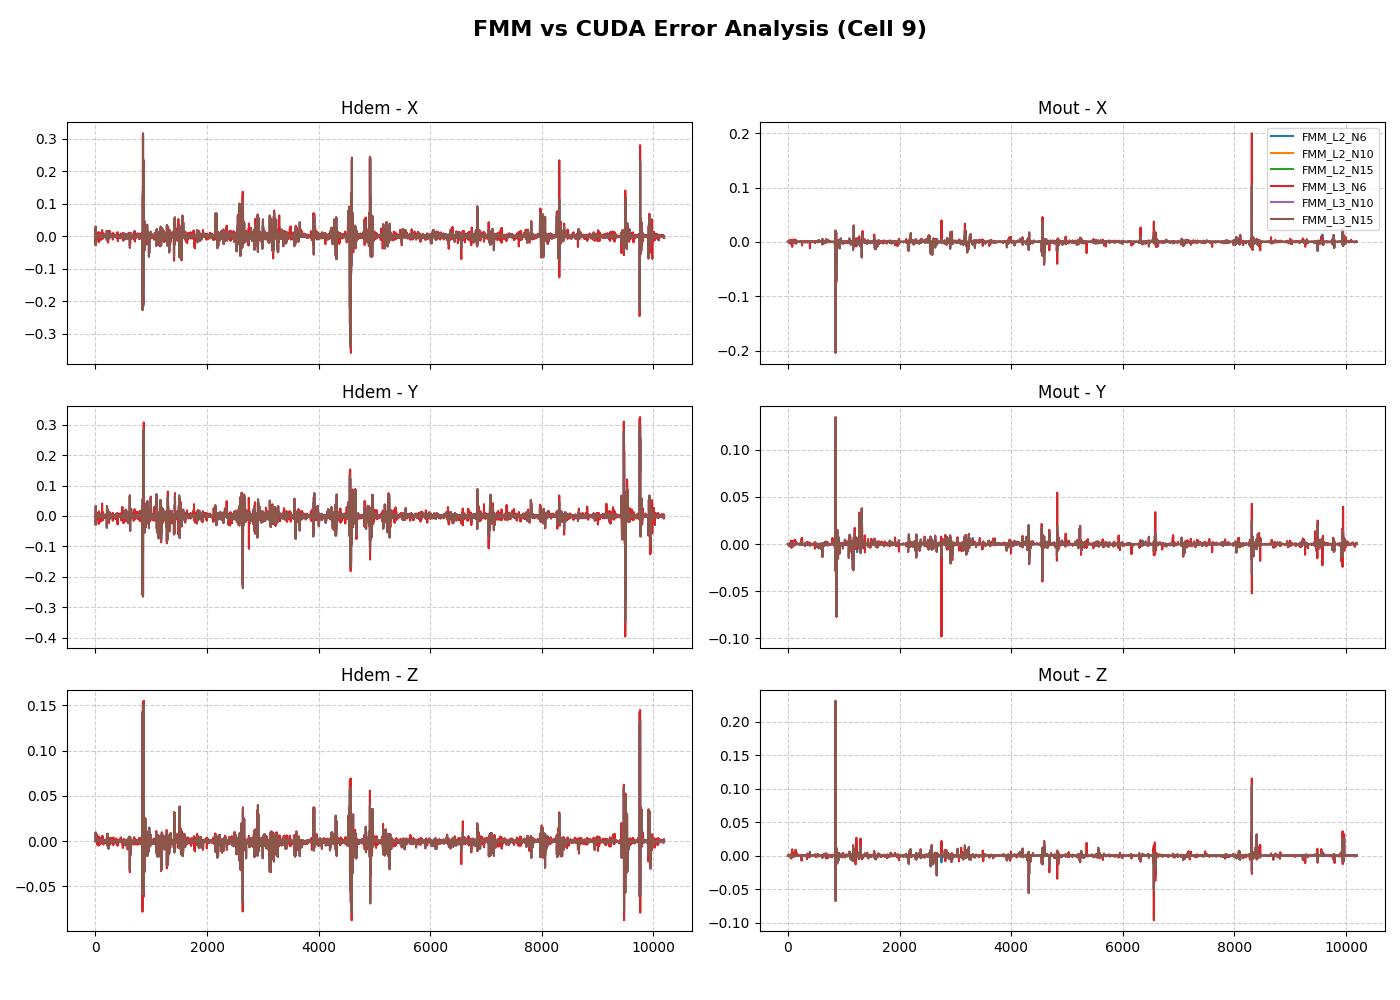

In [11]:
comparison_fig = plot_all_comparisons(results)
plt.show() # Display it in your notebook/UI

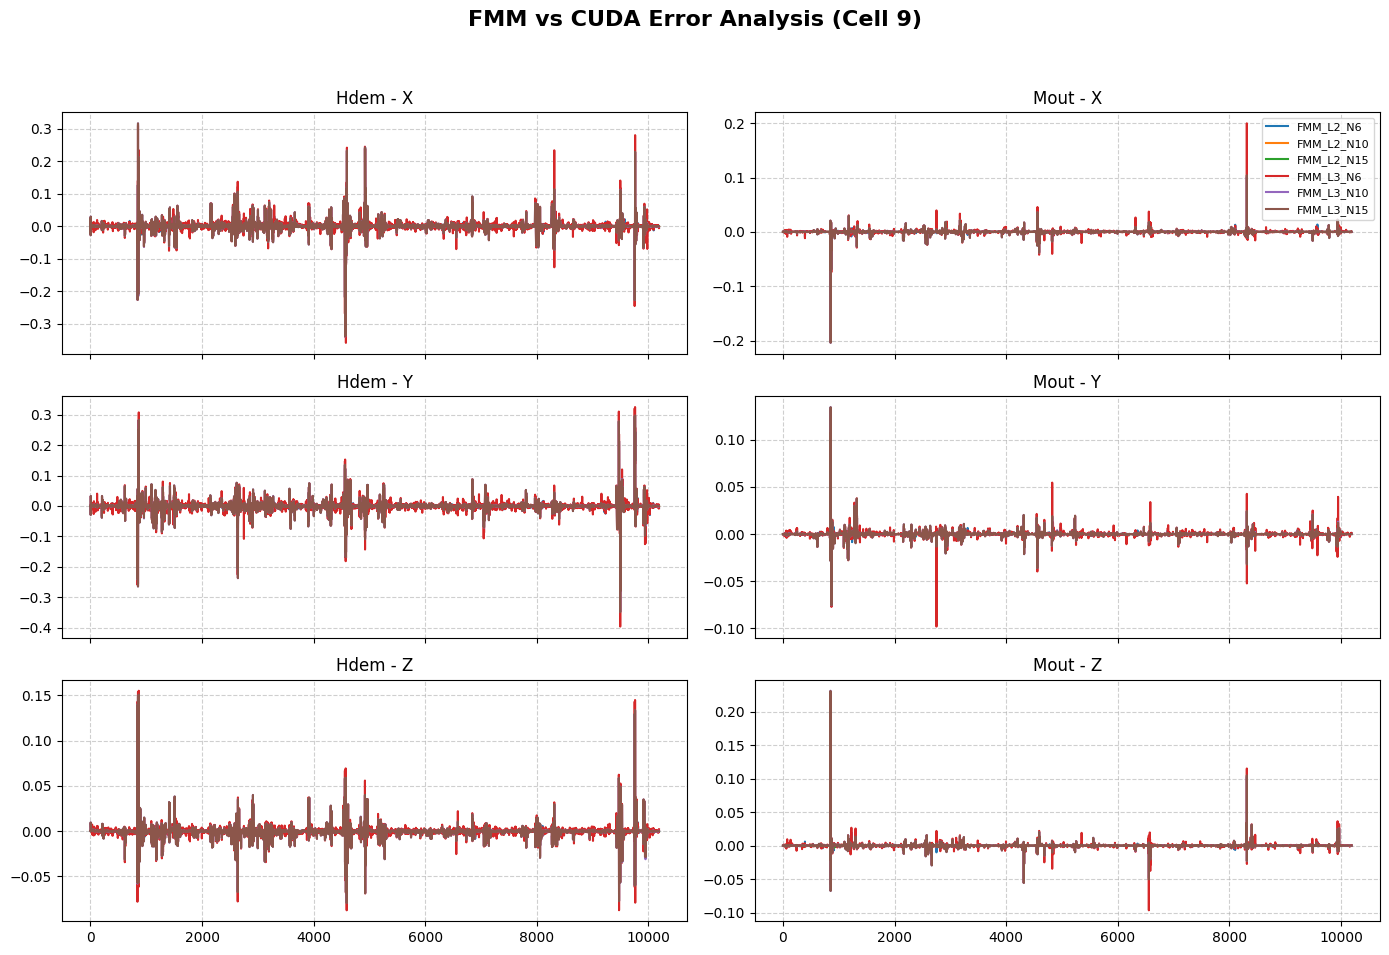

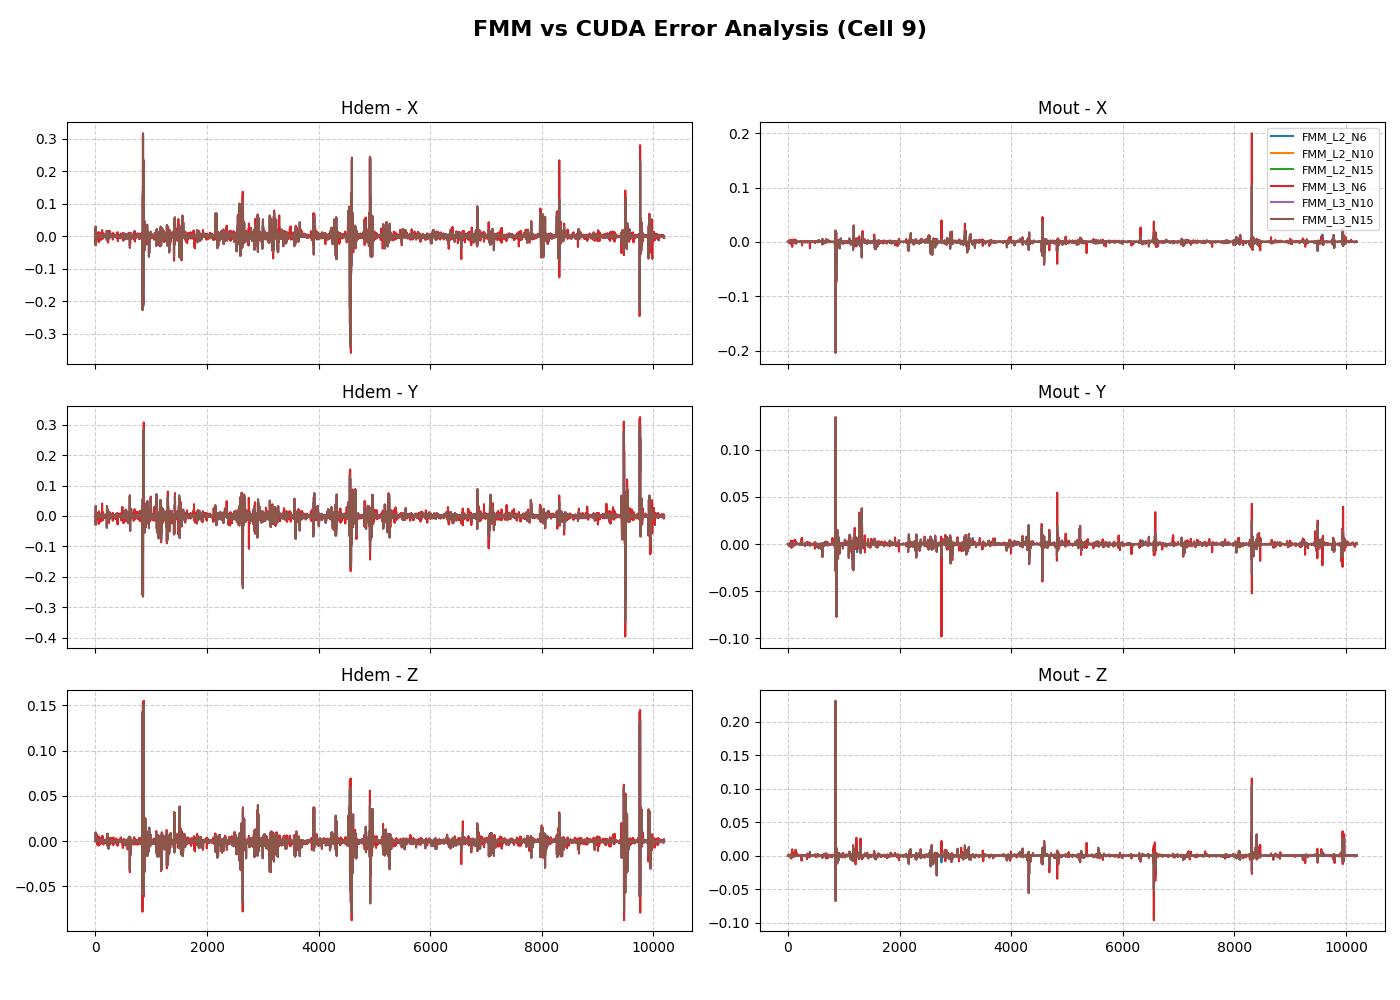

In [12]:
# Run visualization
plot_all_comparisons(results)